# Coverage: time and iterations — `results_ascal_no_restart` vs `results_blind`

**Solid** = `results_ascal_no_restart` (ASCAL, no-reset / carry-state loop). **Dashed** = `results_blind` (blind UCS, applicable successors).

**Time axis:** per run, **x = wall-clock duration** (`end_utc` − `start_utc`) in seconds. Curves are **step curves** over runs **sorted by duration** within each domain; **y** is the cumulative **count** of strict successes (`sound_success_gt`), **not** divided by **n**.

**Iteration axis:** per domain, **i0 = smallest logged iteration count** in that suite (ASCAL: outer iterations; blind: UCS `iterations`). x is **iterations − i0**.

**Coverage (same metric):** cumulative **count** of strict post-loop successes (`sound_success_gt`) in that domain (not divided by **n**).

**Figures in this notebook:** linear and log **time** coverage; linear and log **iteration** coverage; **log–log scatter** of ASCAL demos vs blind UCS `nodes_generated` (matched problems); **positive vs negative** demo counts (ASCAL only).

**ASCAL convergence (explore):** boxplot + scatter of `c/n` from `[sound_complete_convergence]` vs total demos (no blind baseline).

**Full convergence (ASCAL):** table + stacked bars + histogram of `c/n` where **c = n** counts as fully converged (`results_ascal_no_restart`).

In [14]:
from __future__ import annotations

import importlib.util
import json
import re
import sys
from dataclasses import dataclass
from datetime import datetime, timezone
from pathlib import Path
from matplotlib.lines import Line2D

import matplotlib.pyplot as plt
import numpy as np

_here = Path.cwd().resolve()
REPO: Path | None = None
for base in (_here, _here.parent):
    if (base / "benchmarks").is_dir() and (base / "scripts").is_dir():
        REPO = base
        break
if REPO is None:
    for base in (_here, _here.parent):
        if (base / "results_ascal_no_restart").is_dir() or (base / "results_blind").is_dir():
            REPO = base
            break
if REPO is None:
    raise FileNotFoundError("Could not find repo root.")

RESULTS_ASCAL = REPO / "results_ascal_restart"
RESULTS_BLIND = REPO / "results_blind"

MEDIA_DIR = REPO / "media"
MEDIA_DIR.mkdir(parents=True, exist_ok=True)

AGG_PY = REPO / "scripts" / "aggregate_results_server.py"
if not AGG_PY.is_file():
    AGG_PY = _here / "aggregate_results_server.py"
spec = importlib.util.spec_from_file_location("aggregate_results_server", AGG_PY)
agg = importlib.util.module_from_spec(spec)
sys.modules["aggregate_results_server"] = agg
spec.loader.exec_module(agg)
parse_log = agg.parse_log

DOMAINS = ("blocks", "driverlog", "miconic", "satellite")
COLORS = {
    "blocks": "#1f77b4",
    "driverlog": "#ff7f0e",
    "miconic": "#2ca02c",
    "satellite": "#d62728",
}

MARGIN = 0.5
X_SEC_MAX = 3600.0  # plot window (seconds)
X_MIN_LOG_S = 3.6  # equivalent to 10^-3 h
RE_DEMOS = re.compile(r"^\[demos_processed\]\s*(\{.+?\})\s*$", re.MULTILINE)

for p in (RESULTS_ASCAL, RESULTS_BLIND):
    if not p.is_dir():
        print(f"warning: missing {p}")

print("REPO =", REPO)
print("ASCAL =", RESULTS_ASCAL)
print("BLIND =", RESULTS_BLIND)


REPO = /home/pablo/KEPS
ASCAL = /home/pablo/KEPS/results_ascal_restart
BLIND = /home/pablo/KEPS/results_blind


In [15]:
plt.rcParams.update({
    "font.family": "serif",  # pairs well with LaTeX text
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 8,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "figure.dpi": 300,
    "savefig.bbox": "tight",
})

In [16]:
def parse_utc(s: str) -> datetime | None:
    s = (s or "").strip()
    if not s:
        return None
    if s.endswith("Z"):
        s = s[:-1] + "+00:00"
    t = datetime.fromisoformat(s)
    if t.tzinfo is None:
        t = t.replace(tzinfo=timezone.utc)
    return t


@dataclass
class RunEvent:
    domain: str
    problem: str
    start: datetime
    end: datetime
    strict_ok: bool


def load_events(
    results_root: Path,
    domains: tuple[str, ...] = DOMAINS,
) -> tuple[list[RunEvent], dict[str, int]]:
    events: list[RunEvent] = []
    total_logs: dict[str, int] = {d: 0 for d in domains}
    for dom in domains:
        ddir = results_root / dom
        if not ddir.is_dir():
            continue
        for log_path in sorted(ddir.glob("*.log")):
            total_logs[dom] += 1
            text = log_path.read_text(encoding="utf-8", errors="replace")
            row = parse_log(text)
            if row.get("complete") != "1":
                continue
            st = parse_utc(row.get("start_utc", ""))
            en = parse_utc(row.get("end_utc", ""))
            if st is None or en is None:
                continue
            strict = row.get("sound_success_gt") == "1"
            events.append(
                RunEvent(
                    domain=dom,
                    problem=log_path.stem,
                    start=st,
                    end=en,
                    strict_ok=strict,
                )
            )
    events.sort(key=lambda e: e.end)
    return events, total_logs


def load_demo_counts(results_root: Path) -> list[tuple[str, str, int, int]]:
    out: list[tuple[str, str, int, int]] = []
    for dom in DOMAINS:
        ddir = results_root / dom
        if not ddir.is_dir():
            continue
        for log_path in sorted(ddir.glob("*.log")):
            text = log_path.read_text(encoding="utf-8", errors="replace")
            m = RE_DEMOS.search(text)
            if not m:
                continue
            try:
                d = json.loads(m.group(1))
            except json.JSONDecodeError:
                continue
            out.append(
                (
                    dom,
                    log_path.stem,
                    int(d.get("positive_total", 0)),
                    int(d.get("negative_total", 0)),
                )
            )
    return out

@dataclass
class RunIterEvent:
    domain: str
    problem: str
    iterations: int
    strict_ok: bool


def parse_ascal_outer_iterations(text: str) -> int | None:
    """ASCAL: `n_outer` from parse_log (`[online loop]` outer iterations)."""
    row = parse_log(text)
    s = (row.get("n_outer") or "").strip()
    if not s:
        return None
    try:
        return int(s)
    except ValueError:
        return None


def parse_blind_ucs_iterations(text: str) -> int | None:
    """Blind UCS: first `"iterations": …` after `[ucs]`."""
    i = text.find("[ucs]")
    if i < 0:
        return None
    m = re.search(r'"iterations"\s*:\s*(\d+)', text[i : i + 12000])
    if not m:
        return None
    return int(m.group(1))


def load_iter_events(
    results_root: Path,
    kind: str,
    domains: tuple[str, ...] = DOMAINS,
) -> tuple[list[RunIterEvent], dict[str, int]]:
    """Same completeness filter as load_events; attach iteration count per run."""
    events: list[RunIterEvent] = []
    total_logs: dict[str, int] = {d: 0 for d in domains}
    for dom in domains:
        ddir = results_root / dom
        if not ddir.is_dir():
            continue
        for log_path in sorted(ddir.glob("*.log")):
            total_logs[dom] += 1
            text = log_path.read_text(encoding="utf-8", errors="replace")
            row = parse_log(text)
            if row.get("complete") != "1":
                continue
            st = parse_utc(row.get("start_utc", ""))
            en = parse_utc(row.get("end_utc", ""))
            if st is None or en is None:
                continue
            if kind == "no_restart":
                nit = parse_ascal_outer_iterations(text)
            elif kind == "blind":
                nit = parse_blind_ucs_iterations(text)
            else:
                raise ValueError(f"Unknown kind {kind!r}; expected 'no_restart' or 'blind'")
            if nit is None:
                continue
            strict = row.get("sound_success_gt") == "1"
            events.append(
                RunIterEvent(
                    domain=dom,
                    problem=log_path.stem,
                    iterations=nit,
                    strict_ok=strict,
                )
            )
    events.sort(key=lambda e: e.iterations)
    return events, total_logs


events_iv, _ = load_iter_events(RESULTS_ASCAL, "no_restart")
events_ib, _ = load_iter_events(RESULTS_BLIND, "blind")
iter_no_restart = {(e.domain, e.problem): e.iterations for e in events_iv}
iter_blind = {(e.domain, e.problem): e.iterations for e in events_ib}
matched_iter = sorted(set(iter_no_restart) & set(iter_blind))
print(
    f"Iteration maps: no_restart={len(iter_no_restart)} blind={len(iter_blind)} matched={len(matched_iter)}"
)

events_v, total_v = load_events(RESULTS_ASCAL)
events_b, total_b = load_events(RESULTS_BLIND)
Y_COUNT_CAP = int(max(max(total_v.values()), max(total_b.values()), 1))

print(f"ASCAL: {len(events_v)} complete runs")
print(f"BLIND: {len(events_b)} complete runs")
print("per-domain n (logs): ASCAL", {k: total_v[k] for k in DOMAINS})
print("per-domain n (logs): BLIND", {k: total_b[k] for k in DOMAINS})

demos_rows = load_demo_counts(RESULTS_ASCAL)
print(f"ASCAL logs with [demos_processed]: {len(demos_rows)}")


def parse_blind_ucs_nodes_generated(text: str) -> int | None:
    """Blind UCS: first ``"nodes_generated"`` after ``[ucs]`` (if missing, None)."""
    i = text.find("[ucs]")
    if i < 0:
        return None
    m = re.search(r'"nodes_generated"\s*:\s*(\d+)', text[i : i + 12000])
    if not m:
        return None
    return int(m.group(1))


def load_blind_nodes_map(results_root: Path) -> dict[tuple[str, str], int]:
    """Same completeness filter as load_iter_events for blind; value = nodes_generated."""
    out: dict[tuple[str, str], int] = {}
    for dom in DOMAINS:
        ddir = results_root / dom
        if not ddir.is_dir():
            continue
        for log_path in sorted(ddir.glob("*.log")):
            text = log_path.read_text(encoding="utf-8", errors="replace")
            row = parse_log(text)
            if row.get("complete") != "1":
                continue
            st = parse_utc(row.get("start_utc", ""))
            en = parse_utc(row.get("end_utc", ""))
            if st is None or en is None:
                continue
            ng = parse_blind_ucs_nodes_generated(text)
            if ng is None:
                continue
            out[(dom, log_path.stem)] = ng
    return out


nodes_blind = load_blind_nodes_map(RESULTS_BLIND)
demos_tot: dict[tuple[str, str], int] = {
    (d, s): p + n for d, s, p, n in demos_rows
}
matched_ix = sorted(set(demos_tot) & set(nodes_blind))
print(
    f"Interaction maps: norestart_demos={len(demos_tot)} blind_nodes={len(nodes_blind)} matched={len(matched_ix)}"
)


Iteration maps: no_restart=80 blind=80 matched=80
ASCAL: 80 complete runs
BLIND: 80 complete runs
per-domain n (logs): ASCAL {'blocks': 20, 'driverlog': 20, 'miconic': 20, 'satellite': 20}
per-domain n (logs): BLIND {'blocks': 20, 'driverlog': 20, 'miconic': 20, 'satellite': 20}
ASCAL logs with [demos_processed]: 80
Interaction maps: norestart_demos=80 blind_nodes=80 matched=80


## ASCAL convergence only (matched problems with demos)

Uses **`[sound_complete_convergence]`** from `results_ascal_no_restart`: **fraction** = `converged_action_count / domain_action_count` (border-style version space; see `sound_complete_convergence_report` in `loop_ascal_no_restart.py`).

Problems included: **`(domain, stem)` in both `conv_v` and `demos_tot`** (same overlap as demos-based plots, but **no blind** — blind UCS has no version-space convergence to compare).

## Full action convergence — `results_ascal_no_restart` only

From **`[sound_complete_convergence]`**: a run counts as **fully converged** when **`converged_action_count == domain_action_count`** (and `domain_action_count > 0`). This uses the same border-style criterion as `sound_complete_convergence_report` in `loop_ascal_no_restart.py` — not post-loop FD success.

Requires the **imports / paths** cell, the **data-loading** cell (defines `demos_tot`, …), and the **`load_convergence_tuples` / `conv_v`** cell above to have been executed.

In [17]:
RE_SOUND_COMPLETE_CONV = re.compile(
    r"^\[sound_complete_convergence\]\s*(\{.*\})\s*$",
    re.MULTILINE,
)


def load_convergence_tuples(
    results_root: Path,
) -> dict[tuple[str, str], tuple[int, int]]:
    """(domain, stem) -> (converged_action_count, domain_action_count)."""
    out: dict[tuple[str, str], tuple[int, int]] = {}
    for dom in DOMAINS:
        ddir = results_root / dom
        if not ddir.is_dir():
            continue
        for log_path in sorted(ddir.glob("*.log")):
            text = log_path.read_text(encoding="utf-8", errors="replace")
            m = RE_SOUND_COMPLETE_CONV.search(text)
            if not m:
                continue
            try:
                d = json.loads(m.group(1))
            except json.JSONDecodeError:
                continue
            out[(dom, log_path.stem)] = (
                int(d.get("converged_action_count", 0)),
                int(d.get("domain_action_count", 0)),
            )
    return out


conv_v = load_convergence_tuples(RESULTS_ASCAL)
keys_conv = sorted(set(conv_v) & set(demos_tot))
print(
    f"[sound_complete_convergence] in ASCAL: {len(conv_v)} logs; "
    f"overlap with demos_tot: {len(keys_conv)}"
)
if not keys_conv:
    print("(no overlapping keys — run the data-loading cell first, or check logs contain the tag)")

[sound_complete_convergence] in ASCAL: 80 logs; overlap with demos_tot: 80


/tmp/ipykernel_11163/171623734.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


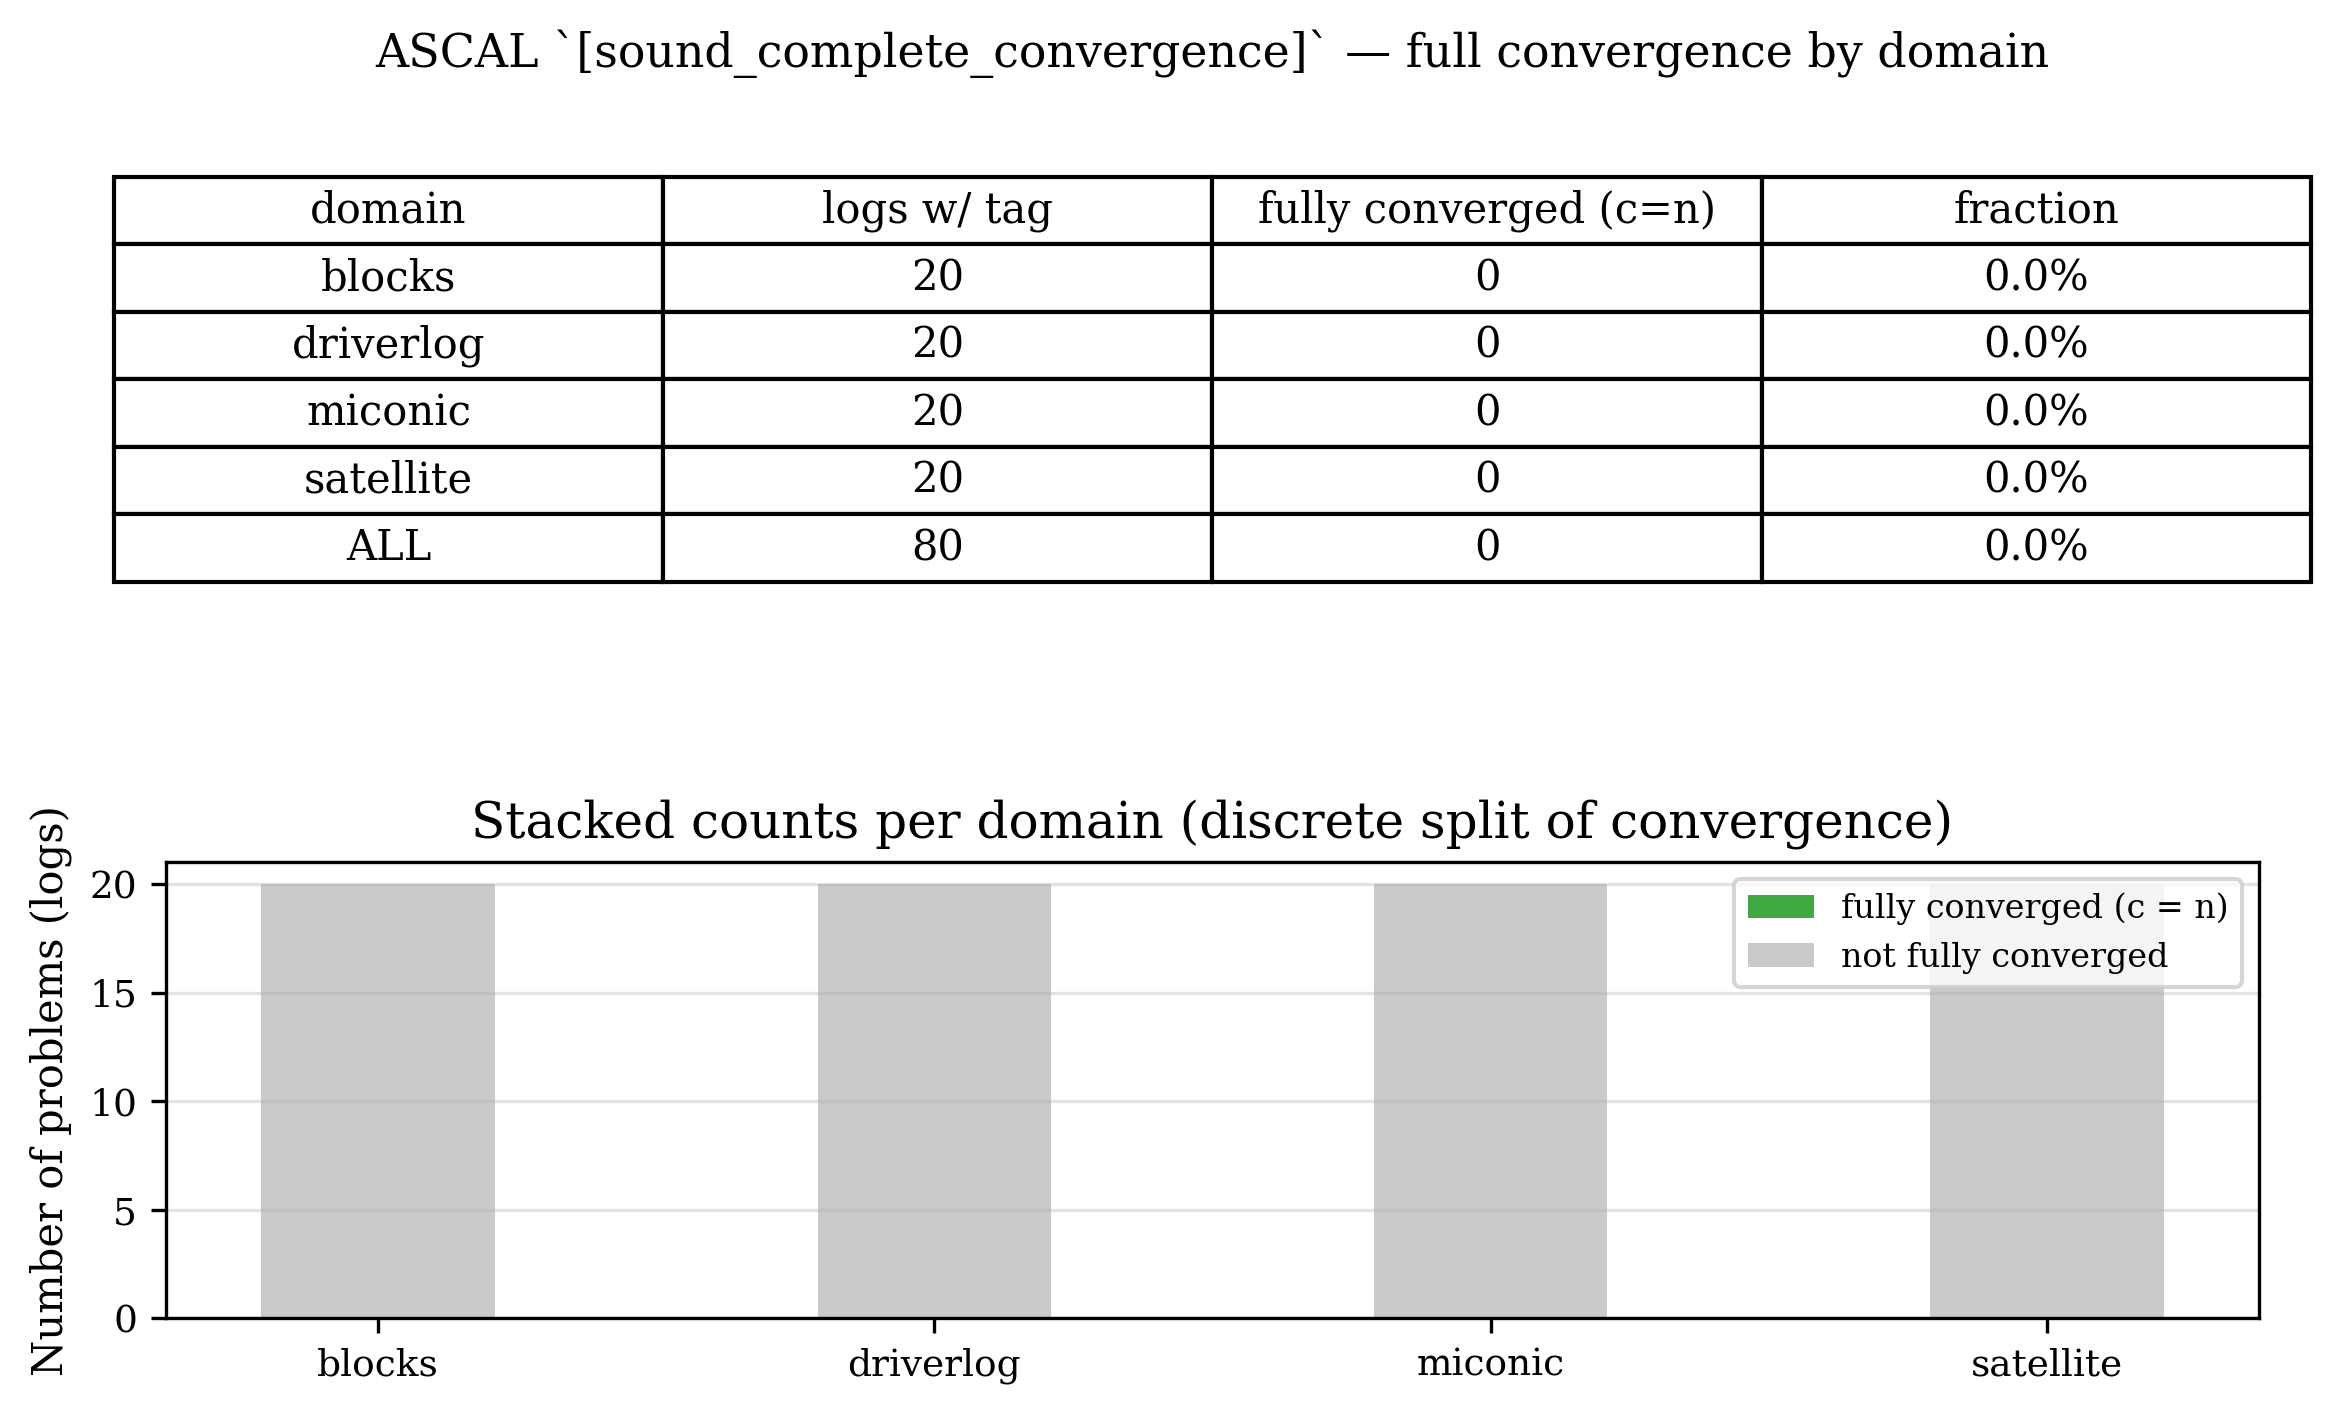

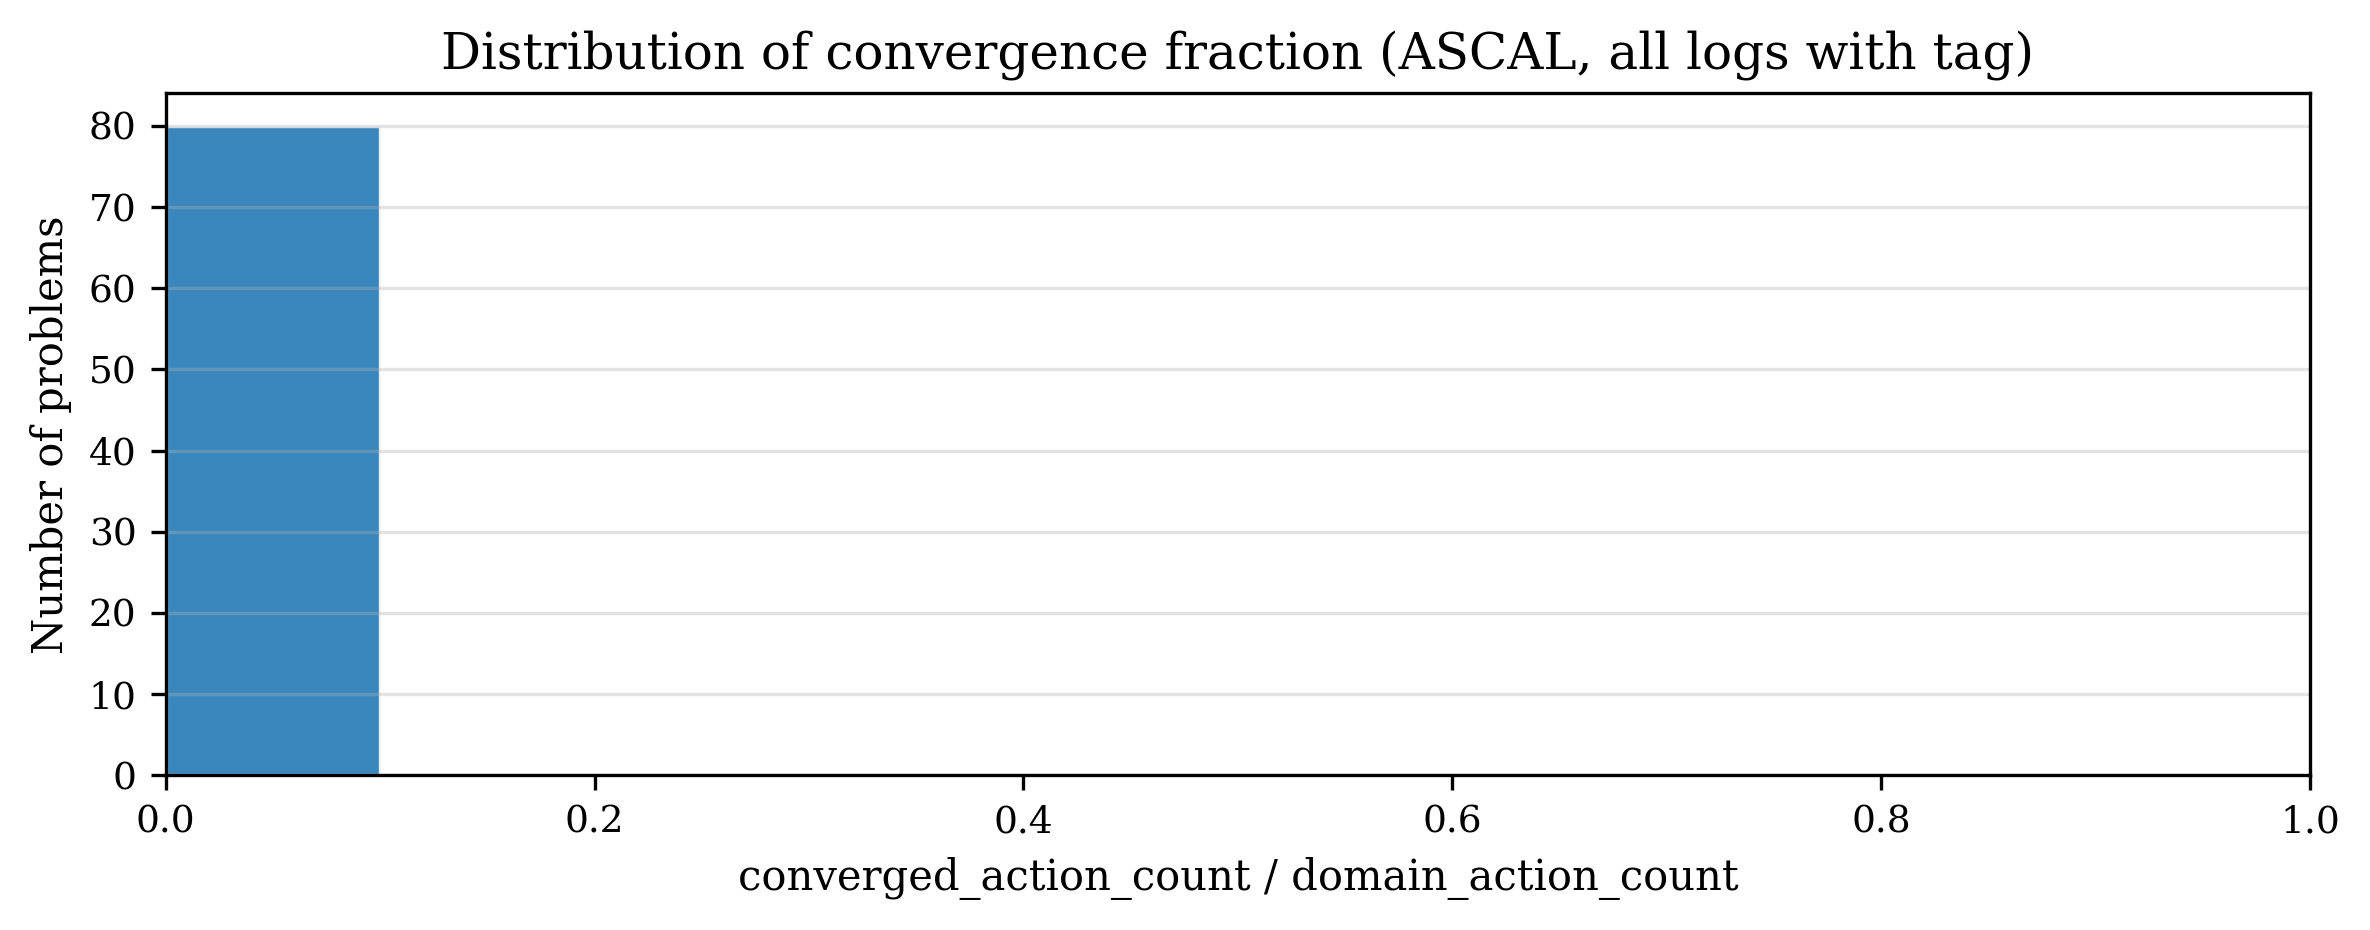

In [18]:
# Full convergence: every domain action has per_action converged == True (summary counts match).
rows_by_dom: dict[str, list[tuple[str, int, int, bool]]] = {d: [] for d in DOMAINS}
for (dom, stem), (c, n) in sorted(conv_v.items()):
    full = n > 0 and c == n
    rows_by_dom[dom].append((stem, c, n, full))

table_rows = []
n_full_total = 0
n_tag_total = 0
for dom in DOMAINS:
    xs = rows_by_dom[dom]
    n_tag = len(xs)
    n_full = sum(1 for _, _, _, ok in xs if ok)
    n_tag_total += n_tag
    n_full_total += n_full
    frac = n_full / n_tag if n_tag else 0.0
    table_rows.append([dom, str(n_tag), str(n_full), f"{100.0 * frac:.1f}%"])

table_rows.append(
    [
        "ALL",
        str(n_tag_total),
        str(n_full_total),
        f"{100.0 * n_full_total / n_tag_total if n_tag_total else 0:.1f}%",
    ]
)

fig = plt.figure(figsize=(9, 5.2))
gs = fig.add_gridspec(2, 1, height_ratios=[1.15, 1.0], hspace=0.45)
ax0 = fig.add_subplot(gs[0, 0])
ax0.axis("off")
tbl = ax0.table(
    cellText=table_rows,
    colLabels=["domain", "logs w/ tag", "fully converged (c=n)", "fraction"],
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.05, 1.35)
ax0.set_title(
    "ASCAL `[sound_complete_convergence]` — full convergence by domain",
    fontsize=11,
    pad=12,
)

ax1 = fig.add_subplot(gs[1, 0])
xpos = np.arange(len(DOMAINS))
w = 0.42
not_full = []
full_only = []
for dom in DOMAINS:
    xs = rows_by_dom[dom]
    n_tag = len(xs)
    n_full = sum(1 for _, _, _, ok in xs if ok)
    full_only.append(n_full)
    not_full.append(n_tag - n_full)

ax1.bar(xpos, full_only, width=w, label="fully converged (c = n)", color="#2ca02c", alpha=0.9)
ax1.bar(xpos, not_full, width=w, bottom=full_only, label="not fully converged", color="#c7c7c7", alpha=0.95)
ax1.set_xticks(xpos, list(DOMAINS))
ax1.set_ylabel("Number of problems (logs)")
ax1.legend(loc="upper right", fontsize=8)
ax1.grid(True, axis="y", alpha=0.35)
ax1.set_title("Stacked counts per domain (discrete split of convergence)")

plt.tight_layout()
plt.show()

# Histogram of convergence fraction c/n (all ASCAL logs with the tag)
fracs_all = [c / max(n, 1) for (_, _), (c, n) in sorted(conv_v.items())]
fig2, ax2 = plt.subplots(figsize=(8, 3.2))
ax2.hist(
    fracs_all,
    bins=np.linspace(0, 1, 11),
    color="#1f77b4",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.88,
)
ax2.set_xlabel("converged_action_count / domain_action_count")
ax2.set_ylabel("Number of problems")
ax2.set_title("Distribution of convergence fraction (ASCAL, all logs with tag)")
ax2.set_xlim(0, 1)
ax2.grid(True, axis="y", alpha=0.35)
fig2.tight_layout()
plt.show()


## Problem coverage - linear (seconds)

In [19]:
def _duration_seconds(e: RunEvent) -> float:
    """Wall seconds for this run (per-problem clock: own start -> own end)."""
    return max(0.0, (e.end - e.start).total_seconds())


def per_domain_step_series(
    events: list[RunEvent],
    totals: dict[str, int],
    domain: str,
    sec_max: float,
) -> tuple[list[float], list[float]]:
    """Step curve: x = wall duration (s); y = cumulative strict-success count."""
    n = totals.get(domain, 0)
    if n <= 0:
        return [0.0, sec_max], [0.0, 0.0]
    evs = sorted(
        (e for e in events if e.domain == domain),
        key=lambda e: (_duration_seconds(e), e.end),
    )
    xs: list[float] = [0.0]
    ys: list[float] = [0.0]
    ok = 0
    for e in evs:
        s = _duration_seconds(e)
        if s > sec_max:
            break
        if e.strict_ok:
            ok += 1
        xs.append(max(0.0, s))
        ys.append(float(ok))
    ok_hi = sum(
        1
        for e in evs
        if e.strict_ok and _duration_seconds(e) <= sec_max
    )
    if xs[-1] < sec_max:
        xs.append(sec_max)
        ys.append(float(ok_hi))
    return xs, ys


def series_for_log_axis(
    events: list[RunEvent],
    totals: dict[str, int],
    domain: str,
    x_lo: float,
    x_hi: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Log x; y = cumulative strict-success count."""
    n = totals.get(domain, 0)
    if n <= 0:
        return np.array([x_lo, x_hi]), np.array([0.0, 0.0])
    evs = sorted(
        (e for e in events if e.domain == domain),
        key=lambda e: (_duration_seconds(e), e.end),
    )
    ok = sum(1 for e in evs if _duration_seconds(e) <= x_lo and e.strict_ok)
    xs: list[float] = [x_lo]
    ys: list[float] = [float(ok)]
    for e in evs:
        s = _duration_seconds(e)
        if s <= x_lo:
            continue
        if s > x_hi:
            break
        if e.strict_ok:
            ok += 1
        xs.append(s)
        ys.append(float(ok))
    ok_hi = sum(
        1 for e in evs if e.strict_ok and _duration_seconds(e) <= x_hi
    )
    if xs[-1] < x_hi:
        xs.append(x_hi)
        ys.append(float(ok_hi))
    return np.array(xs), np.array(ys)


print("Time helpers loaded: x in seconds, y in strict-success counts.")

Time helpers loaded: x in seconds, y in strict-success counts.


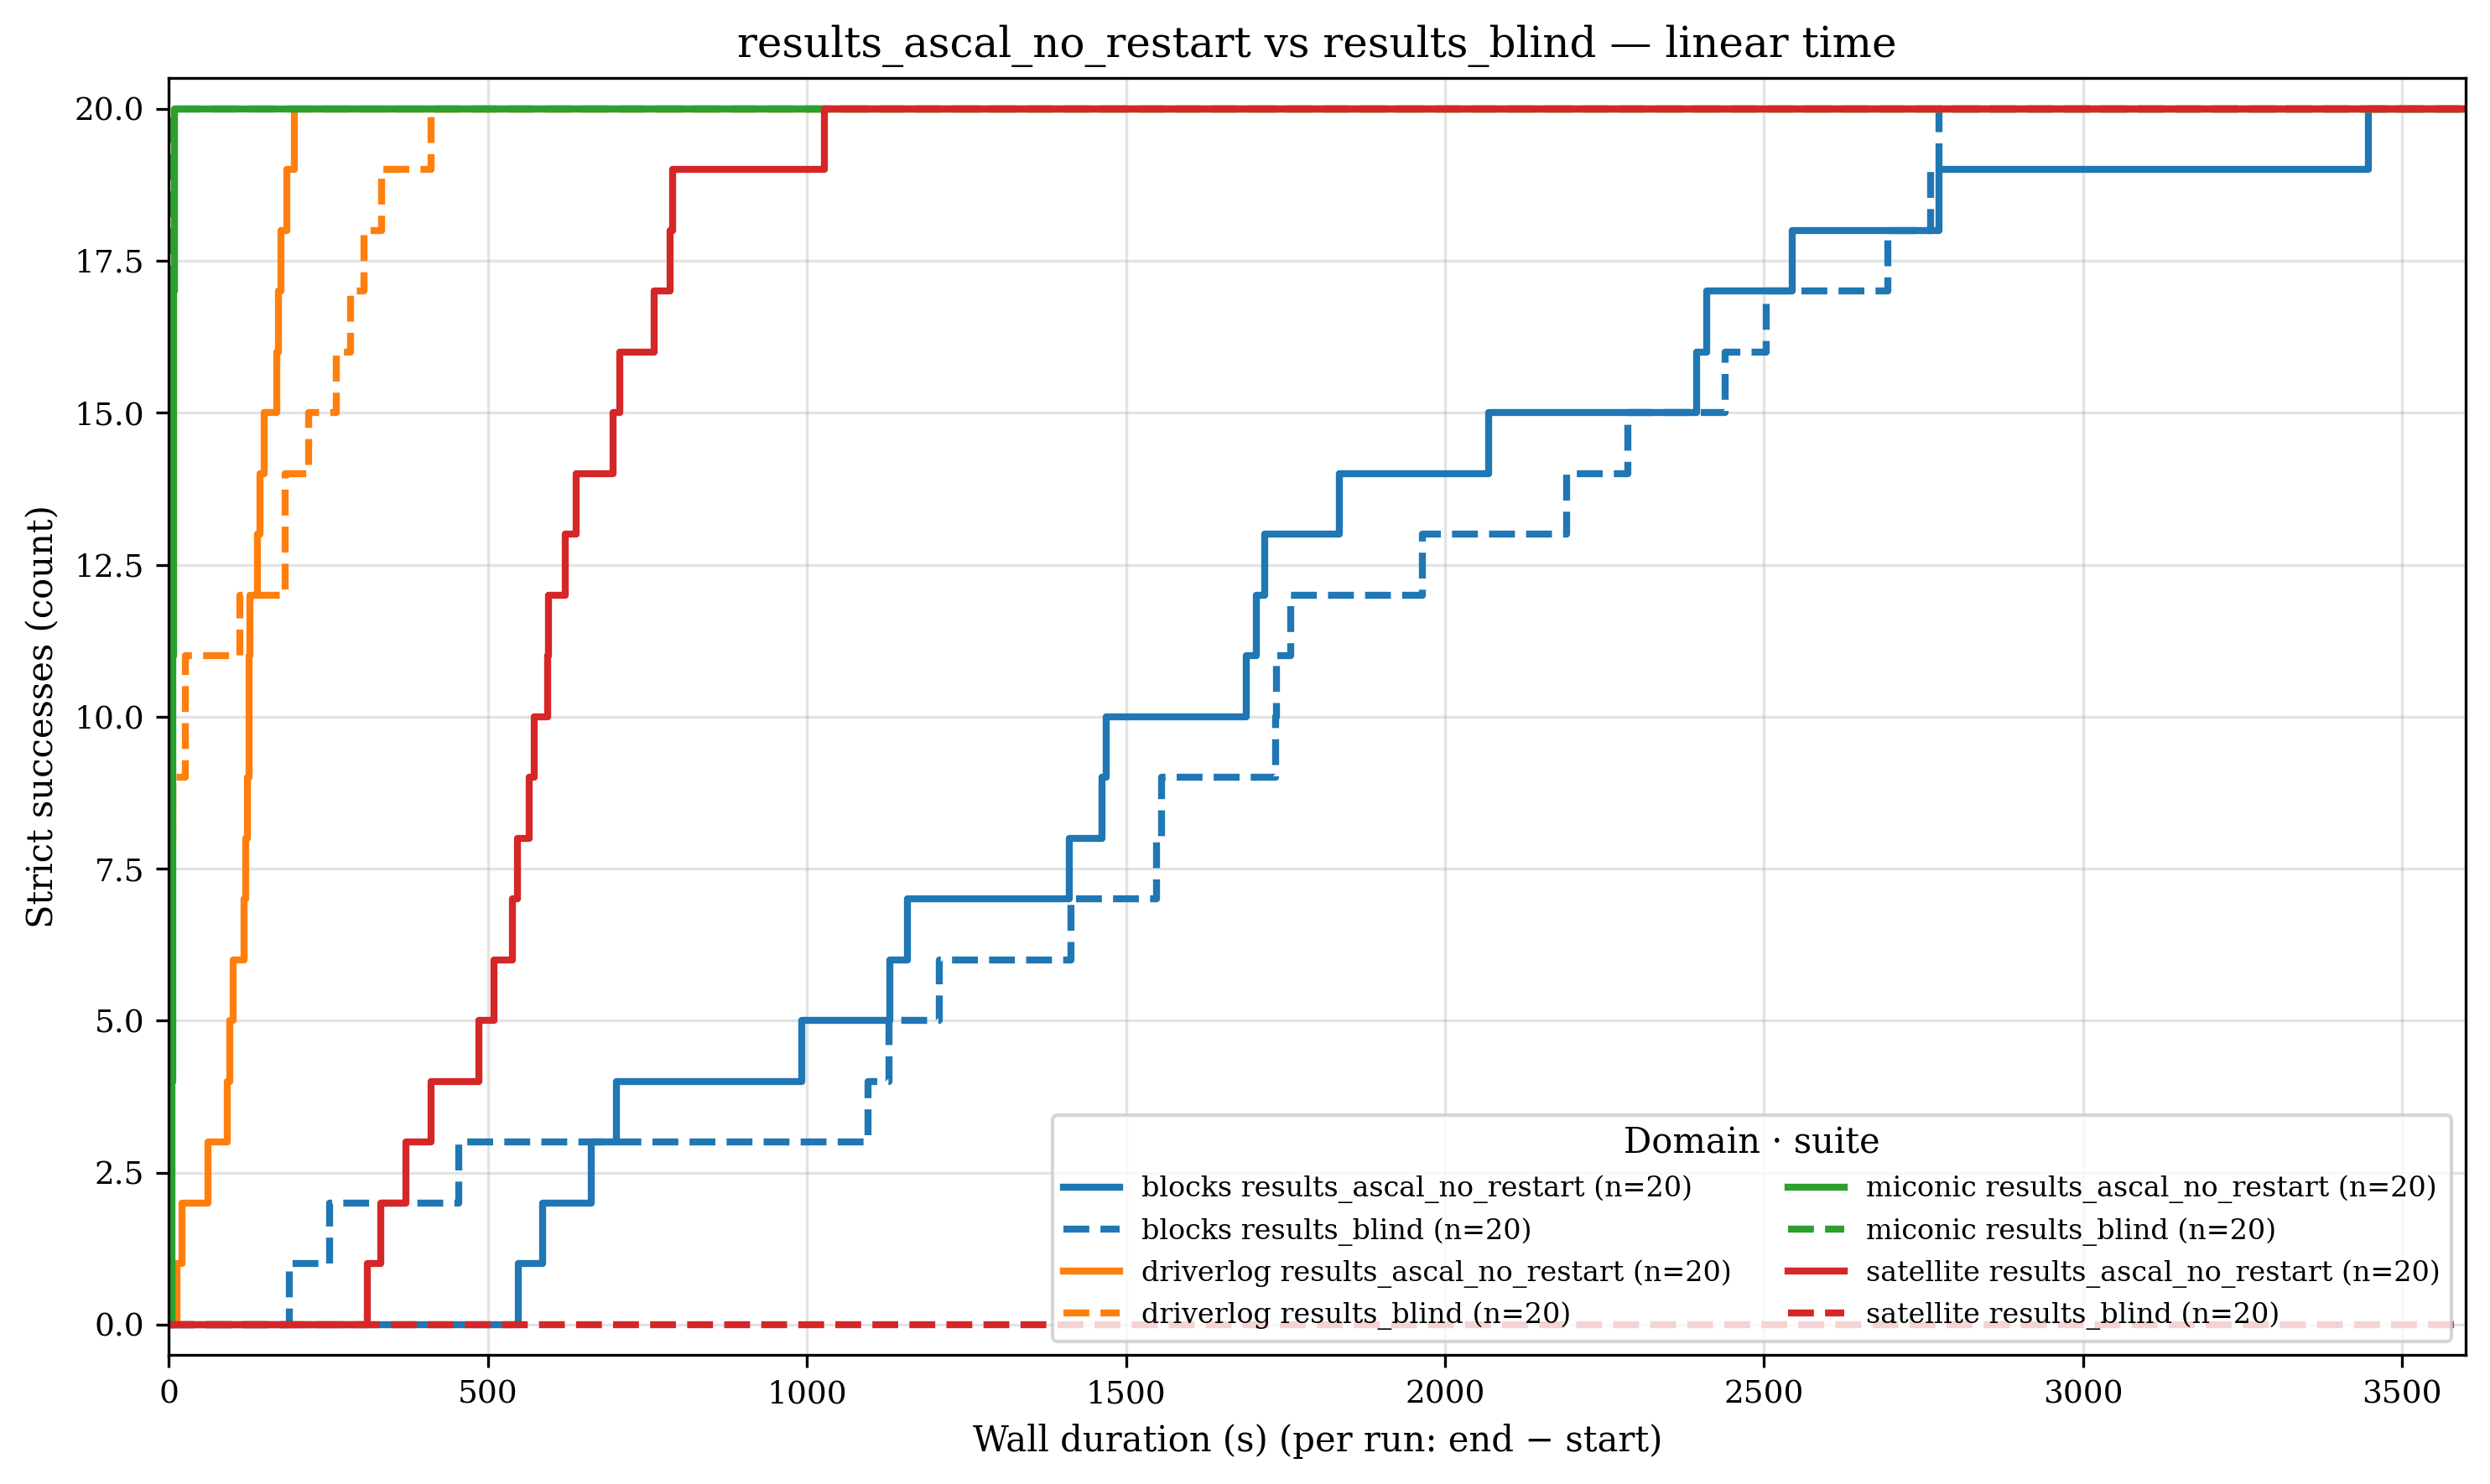

In [20]:
fig, ax = plt.subplots(figsize=(10, 6))
for dom in DOMAINS:
    nv, nb_ = total_v[dom], total_b[dom]
    xv, yv = per_domain_step_series(events_v, total_v, dom, X_SEC_MAX)
    ax.step(
        xv,
        yv,
        where="post",
        color=COLORS[dom],
        linestyle="-",
        linewidth=2,
        label=f"{dom} results_ascal_no_restart (n={nv})",
    )
    xb, yb = per_domain_step_series(events_b, total_b, dom, X_SEC_MAX)
    ax.step(
        xb,
        yb,
        where="post",
        color=COLORS[dom],
        linestyle="--",
        linewidth=2,
        label=f"{dom} results_blind (n={nb_})",
    )
ax.set_xlim(0, X_SEC_MAX)
ax.set_ylim(0 - MARGIN, Y_COUNT_CAP + MARGIN)
ax.set_xlabel("Wall duration (s) (per run: end − start)")
ax.set_ylabel("Strict successes (count)")
ax.set_title("results_ascal_no_restart vs results_blind — linear time")
ax.grid(True, alpha=0.35)
ax.legend(title="Domain · suite", loc="lower right", ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


In [21]:
def i0_for_domain_iter(events: list[RunIterEvent], domain: str) -> int | None:
    evs = [e for e in events if e.domain == domain]
    if not evs:
        return None
    return min(e.iterations for e in evs)


def per_domain_step_series_iter(
    events: list[RunIterEvent],
    totals: dict[str, int],
    domain: str,
    x_max: float,
) -> tuple[list[float], list[float]]:
    """Step curve vs (iterations - i0); y = cumulative strict-success count (not / n)."""
    n = totals.get(domain, 0)
    if n <= 0:
        return [0.0, x_max], [0.0, 0.0]


def series_for_log_axis_iter(
    events: list[RunIterEvent],
    totals: dict[str, int],
    domain: str,
    x_lo: float,
    x_hi: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Log x for iteration offset (iter - i0); y = cumulative strict-success count (not / n)."""
    n = totals.get(domain, 0)
    i0 = i0_for_domain_iter(events, domain)
    if n <= 0 or i0 is None:
        return np.array([x_lo, x_hi]), np.array([0.0, 0.0])
    evs = sorted((e for e in events if e.domain == domain), key=lambda e: e.iterations)
    ok = 0
    for e in evs:
        x = float(e.iterations - i0)
        if x > x_lo:
            break
        if e.strict_ok:
            ok += 1
    xs: list[float] = [x_lo]
    ys: list[float] = [float(ok)]
    for e in evs:
        x = float(e.iterations - i0)
        if x <= x_lo:
            continue
        if x > x_hi:
            break
        if e.strict_ok:
            ok += 1
        xs.append(x)
        ys.append(float(ok))
    ok_hi = sum(
        1
        for e in evs
        if e.strict_ok and float(e.iterations - i0) <= x_hi
    )
    if xs[-1] < x_hi:
        xs.append(x_hi)
        ys.append(float(ok_hi))
    return np.array(xs), np.array(ys)


def max_iter_offset(events: list[RunIterEvent]) -> float:
    m = 0.0
    for dom in DOMAINS:
        i0 = i0_for_domain_iter(events, dom)
        if i0 is None:
            continue
        for e in events:
            if e.domain == dom:
                m = max(m, float(e.iterations - i0))
    return max(m, 1.0)


X_ITER_MAX = max(max_iter_offset(events_iv), max_iter_offset(events_ib)) * 1.05
X_MIN_LOG_ITER = 1.0
print(
    "Iteration origin: per domain, per suite (min iteration in that domain). "
    f"X_ITER_MAX≈{X_ITER_MAX:.0f}"
)

Iteration origin: per domain, per suite (min iteration in that domain). X_ITER_MAX≈701777


## Problem coverage - log (seconds)

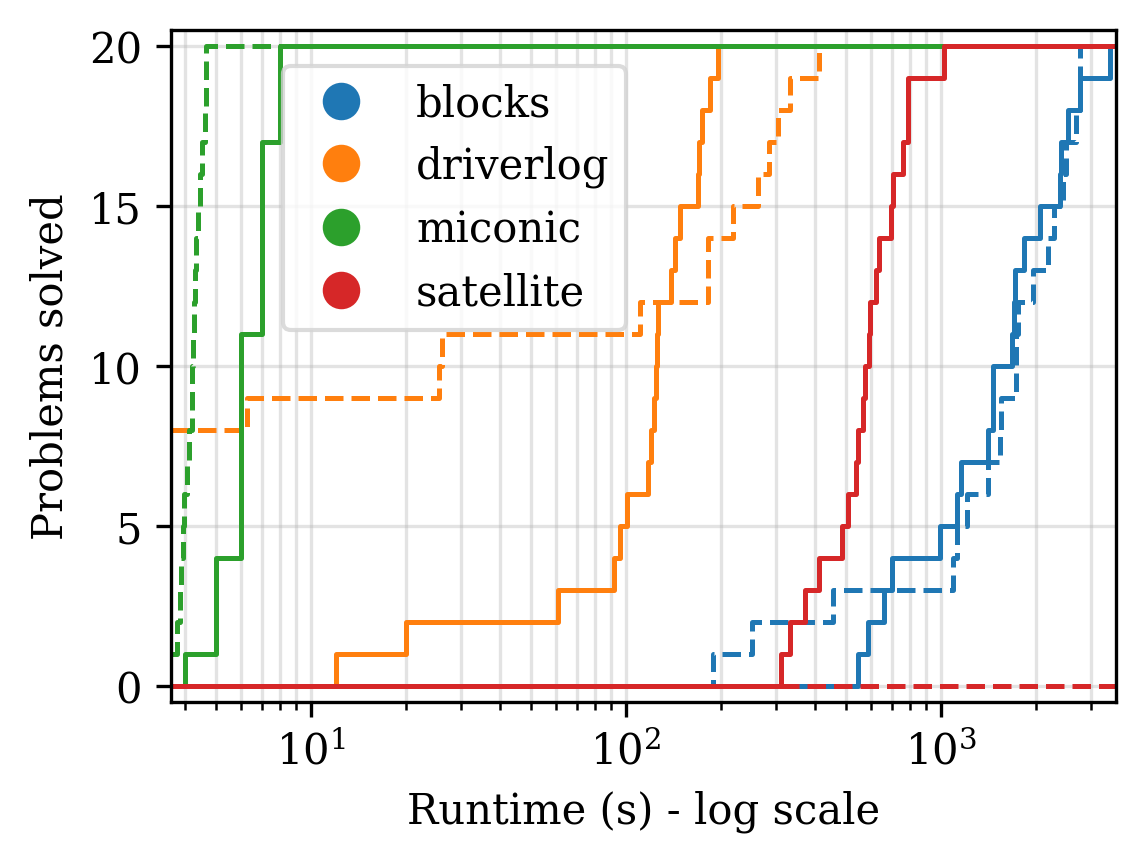

In [22]:
# Single-column style (vector text in PDF)
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(4.5, 3.2))
for dom in DOMAINS:
    xv, yv = series_for_log_axis(events_v, total_v, dom, X_MIN_LOG_S, X_SEC_MAX)
    ax.step(
        xv,
        yv,
        where="post",
        color=COLORS[dom],
        linestyle="-",
        linewidth=1.2,
        label=f"{dom}",
    )
    xb, yb = series_for_log_axis(events_b, total_b, dom, X_MIN_LOG_S, X_SEC_MAX)
    ax.step(
        xb,
        yb,
        where="post",
        color=COLORS[dom],
        linestyle="--",
        linewidth=1.2,
    )
ax.set_xscale("log")
ax.set_xlim(X_MIN_LOG_S, X_SEC_MAX)
ax.set_ylim(0 - MARGIN, Y_COUNT_CAP + MARGIN)
ax.set_xlabel("Runtime (s) - log scale")
ax.set_ylabel("Problems solved")
ax.set_title("")
ax.grid(True, which="both", alpha=0.35)
handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color=COLORS[d],
        linestyle="",
        markersize=8,
        label=d,
    )
    for d in DOMAINS
]
ax.legend(
    handles=handles,
    loc="center",
    bbox_to_anchor=(0.3, 0.75),
    ncol=1,
    frameon=True,
    framealpha=0.8,
    edgecolor="lightgray",
    fontsize=10,
)
plt.subplots_adjust(left=0.2, right=0.9, top=0.9, bottom=0.2)
plt.savefig(MEDIA_DIR / "time.pdf", format="pdf", bbox_inches="tight", pad_inches=0.01)
plt.show()

## Coverage vs iterations

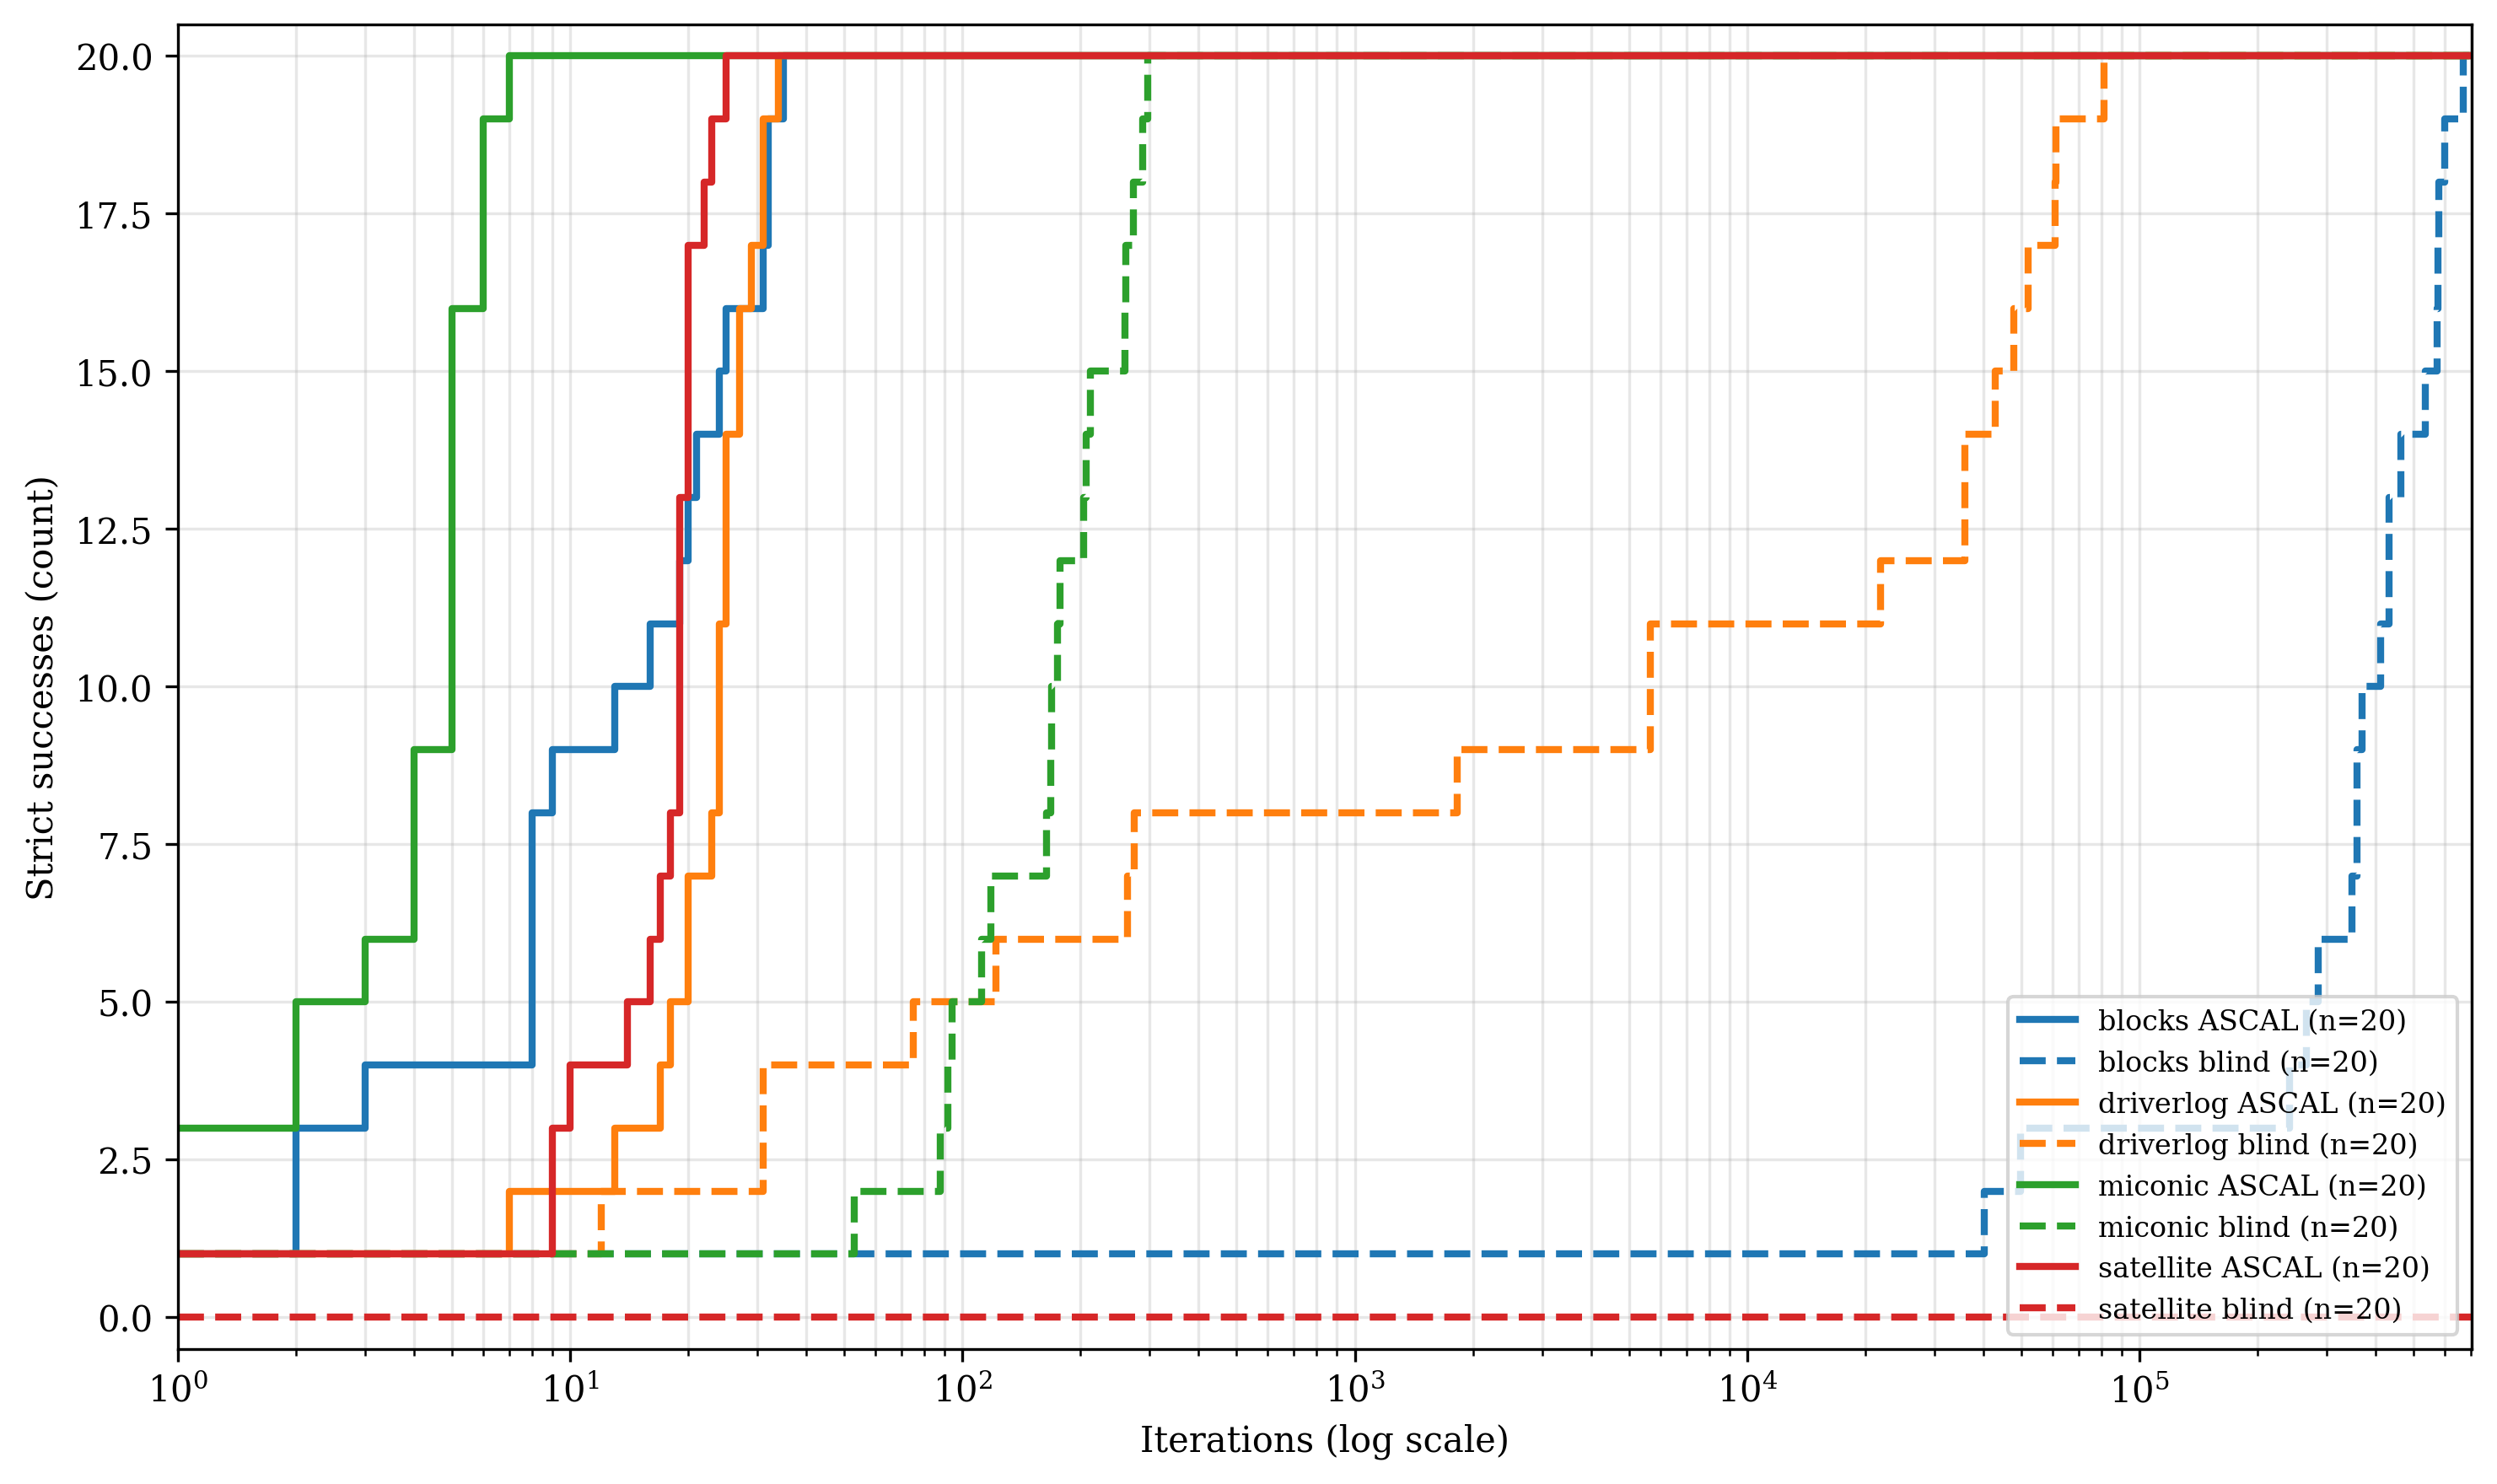

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
for dom in DOMAINS:
    nv, nb_ = total_v[dom], total_b[dom]
    xv, yv = series_for_log_axis_iter(events_iv, total_v, dom, X_MIN_LOG_ITER, X_ITER_MAX)
    ax.step(
        xv,
        yv,
        where="post",
        color=COLORS[dom],
        linestyle="-",
        linewidth=2,
        label=f"{dom} ASCAL (n={nv})",
    )
    xb, yb = series_for_log_axis_iter(events_ib, total_b, dom, X_MIN_LOG_ITER, X_ITER_MAX)
    ax.step(
        xb,
        yb,
        where="post",
        color=COLORS[dom],
        linestyle="--",
        linewidth=2,
        label=f"{dom} blind (n={nb_})",
    )
ax.set_xscale("log")
ax.set_xlim(X_MIN_LOG_ITER, X_ITER_MAX)
ax.set_ylim(0 - MARGIN, Y_COUNT_CAP + MARGIN)
ax.set_xlabel("Iterations (log scale)")
ax.set_ylabel("Strict successes (count)")
#ax.set_title("ASCAL vs blind — log iterations")
ax.grid(True, which="both", alpha=0.3)
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
plt.savefig(MEDIA_DIR / "iterations.png", format="png")
plt.show()

## Scatter: ASCAL total demos vs blind nodes_generated

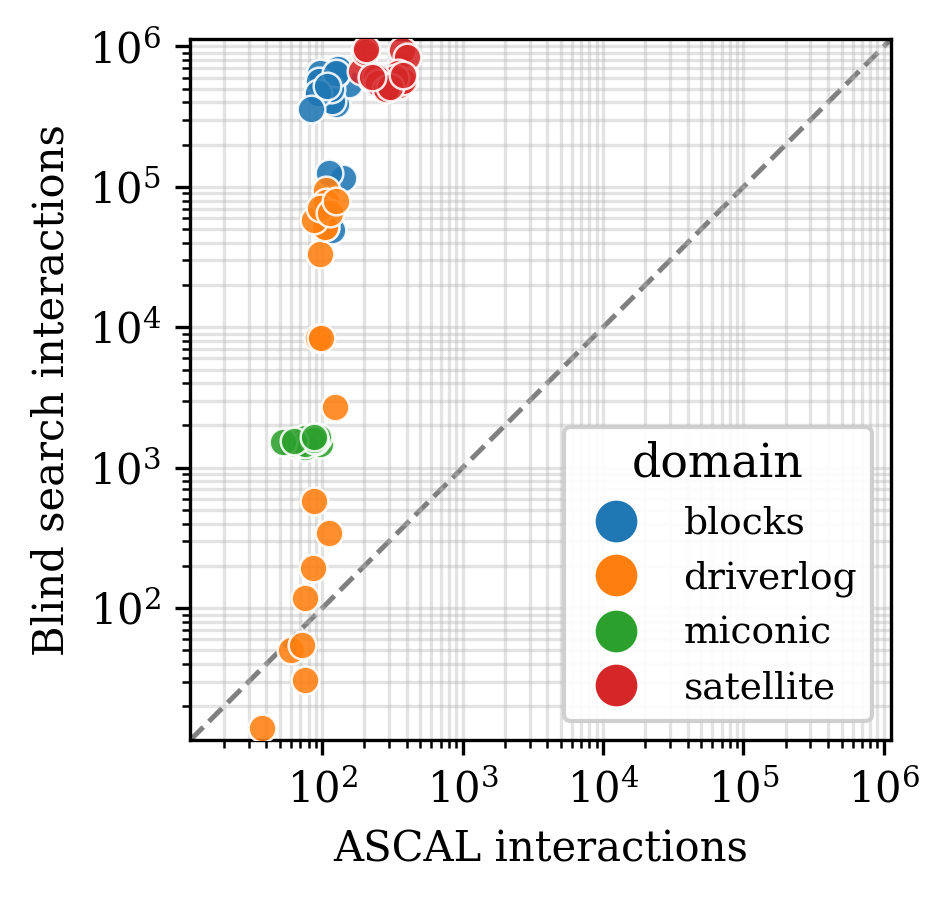

In [24]:
from matplotlib.lines import Line2D

# Log axes: floor at 1.0 only when that axis is log (matplotlib requires strictly positive data).
LOG_X_DEMOS_VS_BLIND = True
LOG_Y_DEMOS_VS_BLIND = True
# If both log: shared (lo, hi) on x and y so decades match — points sit toward the lower-left.
SAME_XY_AXIS_LIMITS = True

keys_ix = sorted(matched_ix, key=lambda k: (k[0], k[1]))
xs = np.asarray([float(demos_tot[k]) for k in keys_ix], dtype=float)
ys = np.asarray([float(nodes_blind[k]) for k in keys_ix], dtype=float)
x_plot = np.maximum(xs, 1.0) if LOG_X_DEMOS_VS_BLIND else xs
y_plot = np.maximum(ys, 1.0) if LOG_Y_DEMOS_VS_BLIND else ys

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

fig, ax = plt.subplots(figsize=(3.2, 3.2))
for k, xv, yv in zip(keys_ix, x_plot, y_plot):
    dom, _ = k
    ax.scatter(
        xv,
        yv,
        color=COLORS[dom],
        s=44,
        alpha=0.88,
        edgecolors="white",
        linewidths=0.6,
        zorder=3,
    )

if LOG_X_DEMOS_VS_BLIND:
    ax.set_xscale("log")
if LOG_Y_DEMOS_VS_BLIND:
    ax.set_yscale("log")

xmin, xmax = float(x_plot.min()), float(x_plot.max())
ymin, ymax = float(y_plot.min()), float(y_plot.max())
if (
    SAME_XY_AXIS_LIMITS
    and LOG_X_DEMOS_VS_BLIND
    and LOG_Y_DEMOS_VS_BLIND
):
    lo = min(xmin, ymin)
    hi = max(xmax, ymax)
    ax.set_xlim(lo * 0.82, hi * 1.18)
    ax.set_ylim(lo * 0.82, hi * 1.18)
    ax.set_aspect("equal", adjustable="box")
else:
    if LOG_X_DEMOS_VS_BLIND:
        ax.set_xlim(xmin * 0.85, xmax * 1.15)
    else:
        ax.set_xlim(0.0, xmax * 1.05 if xmax > 0 else 1.0)
    if LOG_Y_DEMOS_VS_BLIND:
        ax.set_ylim(ymin * 0.85, ymax * 1.15)
    else:
        ax.set_ylim(0.0, ymax * 1.05 if ymax > 0 else 1.0)

ax.set_xlabel(
    "ASCAL interactions",
)
ax.set_ylabel("Blind search interactions")
ax.grid(True, alpha=0.35, which="both")

if SAME_XY_AXIS_LIMITS and LOG_X_DEMOS_VS_BLIND and LOG_Y_DEMOS_VS_BLIND:
    xlo, xhi = ax.get_xlim()
    ax.plot([xlo, xhi], [xlo, xhi], color="gray", linestyle="--", linewidth=1.2, zorder=1, label="y = x")
else:
    r0 = max(min(float(x_plot.min()), float(y_plot.min())), 1e-12)
    r1 = max(float(x_plot.max()), float(y_plot.max()))
    ax.plot([r0, r1], [r0, r1], color="gray", linestyle="--", linewidth=1.2, zorder=1, label="y = x")

handles = [
    Line2D([0], [0], marker="o", color=COLORS[d], linestyle="", markersize=9, label=d)
    for d in DOMAINS
]
ax.legend(handles=handles, title="domain", loc="lower right", framealpha=0.92)
plt.subplots_adjust(left=0.22, right=0.95, top=0.95, bottom=0.18)
plt.savefig(MEDIA_DIR / "nodes_vs_demos.pdf", format="pdf", pad_inches=0.025)
plt.show()

## Scatter: positive vs negative demos (ASCAL)

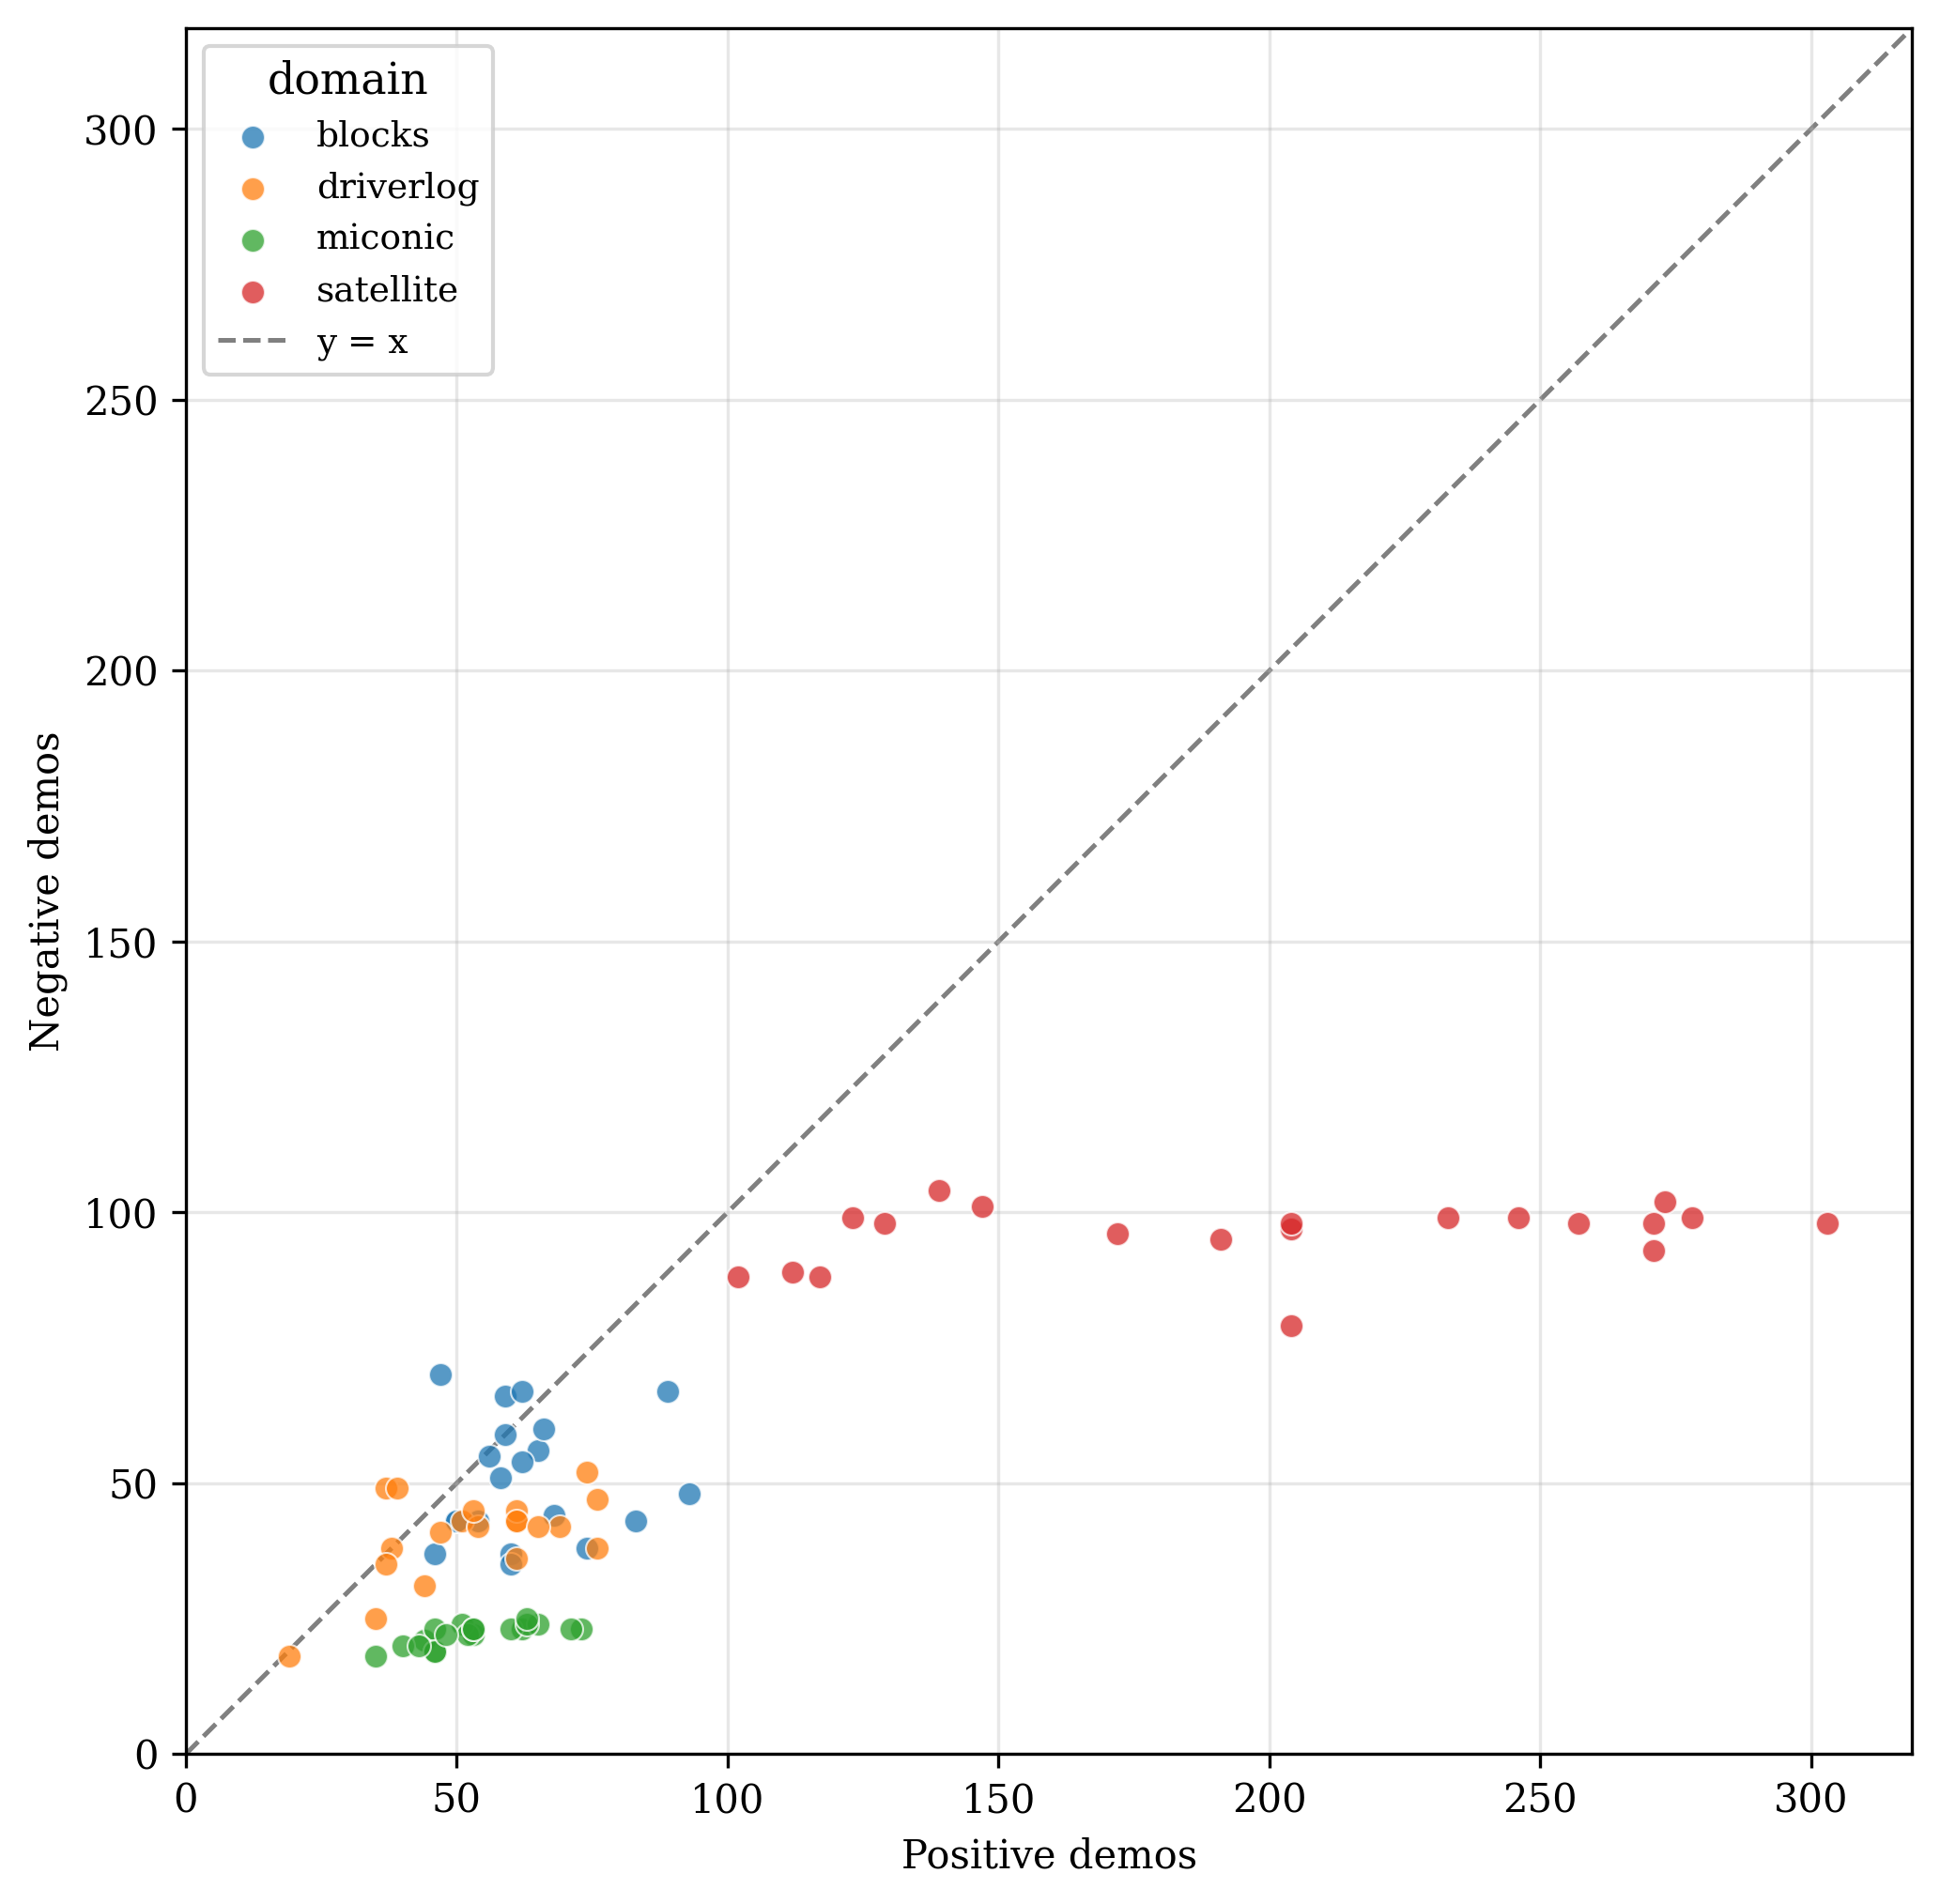

In [25]:
fig, ax = plt.subplots(figsize=(7, 7))
for dom in DOMAINS:
    pts = [(p, n) for d, _, p, n in demos_rows if d == dom]
    if not pts:
        continue
    px, py = zip(*pts)
    ax.scatter(
        px,
        py,
        c=COLORS[dom],
        label=dom,
        alpha=0.75,
        edgecolors="white",
        linewidths=0.5,
        zorder=2,
    )

pos_all = [p for _, _, p, _ in demos_rows]
neg_all = [n for _, _, _, n in demos_rows]
hi_data = max(max(pos_all, default=0), max(neg_all, default=0), 1)
hi = hi_data * 1.05 + 0.5  # small padding so points are not on the frame
ax.set_xlim(0, hi)
ax.set_ylim(0, hi)
ax.set_aspect("equal", adjustable="box")
ax.plot([0, hi], [0, hi], color="gray", linestyle="--", linewidth=1.2, zorder=1, label="y = x")

ax.set_xlabel("Positive demos")
ax.set_ylabel("Negative demos")
#ax.set_title("Per-problem demos — results_ascal_no_restart (ASCAL) only")
ax.grid(True, alpha=0.3)
ax.legend(title="domain")
plt.tight_layout()
plt.savefig(MEDIA_DIR / "positive_vs_negative_demos.png", format="png")
plt.show()



Logs found: 80
Logs with [summary]: 80
Problems finished with sound mode (plan_found_sound == 1) by domain:
  blocks: 5
  driverlog: 14
  miconic: 19
  satellite: 20


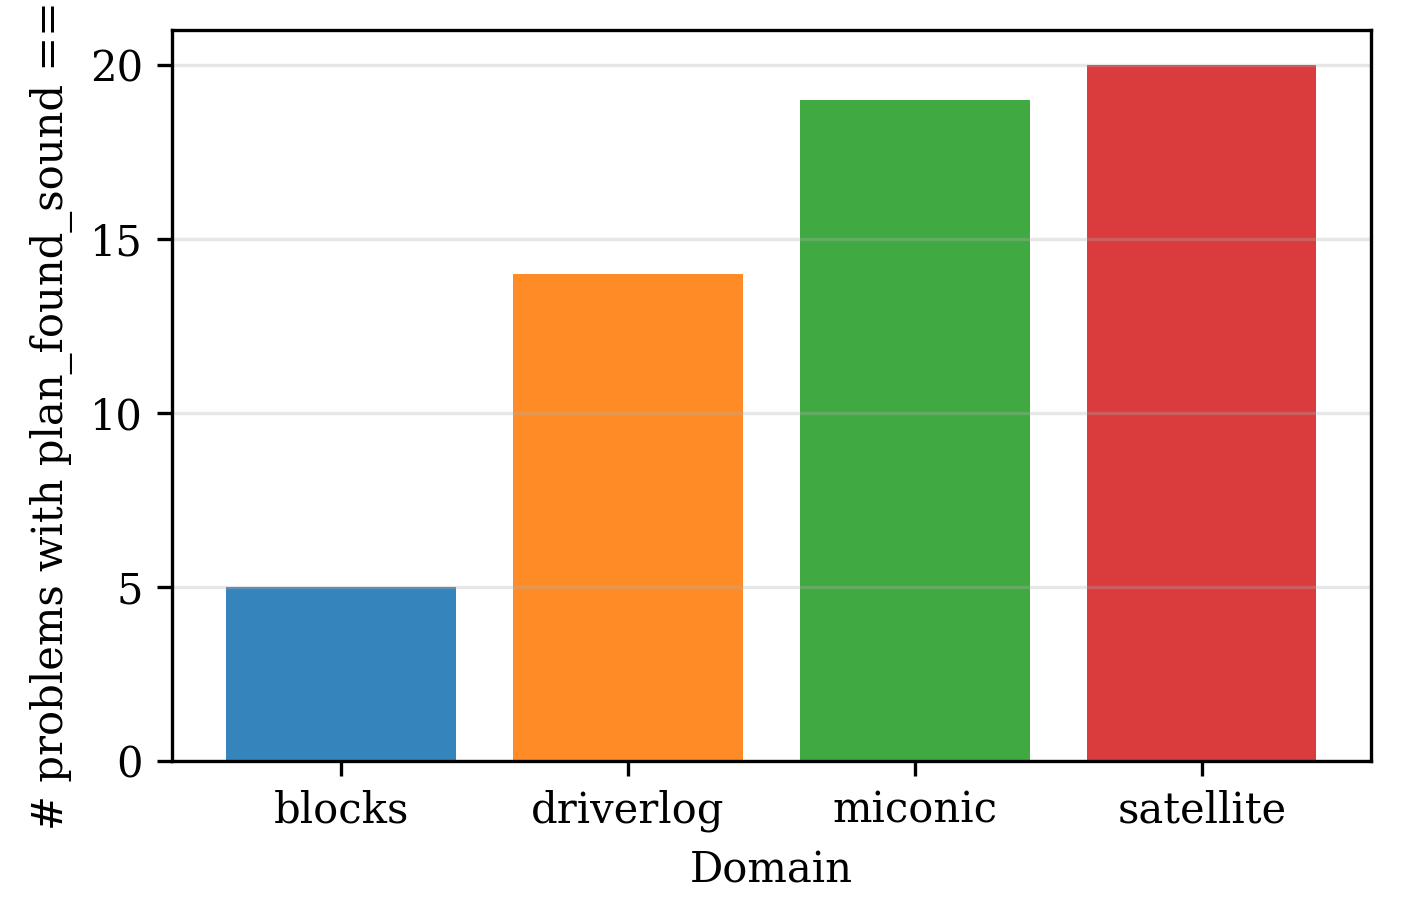

In [26]:
# Count problems finished in sound mode per domain in results_ascal_no_restart.
# A valid summary must have plan_found_sound in {0, 1}.
import ast

summary_re = re.compile(r"^\[summary\]\s*(\{.*\})")
log_paths = sorted(RESULTS_ASCAL.glob("*/*.log"))

sound_finished_by_domain = {d: 0 for d in DOMAINS}
checked_logs = 0

for log_path in log_paths:
    domain = log_path.parent.name
    if domain not in sound_finished_by_domain:
        continue

    summary_dict = None
    with log_path.open("r", encoding="utf-8", errors="replace") as fh:
        for line in fh:
            m = summary_re.match(line.strip())
            if m:
                summary_dict = ast.literal_eval(m.group(1))
                break

    if summary_dict is None:
        continue

    if "plan_found_sound" not in summary_dict:
        raise KeyError(f"Missing 'plan_found_sound' in summary: {log_path}")

    value = summary_dict["plan_found_sound"]
    if value < 0 or value > 1:
        raise ValueError(
            f"Invalid plan_found_sound={value} in {log_path}; expected 0 or 1"
        )

    checked_logs += 1
    if value == 1:
        sound_finished_by_domain[domain] += 1

print(f"Logs found: {len(log_paths)}")
print(f"Logs with [summary]: {checked_logs}")
print("Problems finished with sound mode (plan_found_sound == 1) by domain:")
for dom in DOMAINS:
    print(f"  {dom}: {sound_finished_by_domain[dom]}")

# Bar plot per domain.
xpos = np.arange(len(DOMAINS))
counts = [sound_finished_by_domain[d] for d in DOMAINS]

fig, ax = plt.subplots(figsize=(4.8, 3.2))
ax.bar(xpos, counts, color=[COLORS[d] for d in DOMAINS], alpha=0.9)
ax.set_xticks(xpos, list(DOMAINS))
ax.set_ylabel("# problems with plan_found_sound == 1")
ax.set_xlabel("Domain")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()